In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from pandas.plotting import scatter_matrix
from scipy.stats import ttest_ind
import scipy.stats as sps


In [84]:
# Load the data from the FITS file given. 
dr3stars = fits.open('gaiadr3_cluster_stars.fits')
dr3stars.info()
print(dr3stars[1].columns)
stars = pd.DataFrame(dr3stars[1].data)
stars['Name'] = stars['Name'].str.strip()

clcounts = stars.groupby(['Name']).size().reset_index(name='count')

Filename: gaiadr3_cluster_stars.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      93   ()      
  1  members.dat    1 TableHDU       331   1291929R x 56C   [A20, I4, I19, I1, F10.8, F12.8, F10.8, F12.8, F10.8, F12.8, E11.4, E11.4, F10.8, E11.4, F10.8, E11.4, F10.8, F11.8, F11.8, E11.4, E11.4, E11.4, E11.4, E11.4, E11.4, I2, F12.8, F10.7, F11.8, F10.8, F19.8, F16.8, F18.8, F17.8, F18.8, F17.8, F10.7, F10.7, F10.7, E11.4, E11.4, E11.4, E9.3, F12.8, F4.1, F6.1, F5.1, F11.7, F11.8, F6.1, F12.7, F13.8, F5.1, A13, I1, I1]   
ColDefs(
    name = 'Name'; format = 'A20'; start = 1
    name = 'ID'; format = 'I4'; disp = 'I4'; start = 22
    name = 'GaiaDR3'; format = 'I19'; disp = 'I19'; start = 27
    name = 'inrt'; format = 'I1'; disp = 'I1'; start = 47
    name = 'Prob'; format = 'F10.8'; disp = 'F10.8'; start = 49
    name = 'RAdeg'; format = 'F12.8'; unit = 'deg'; disp = 'F12.8'; start = 60
    name = 'e_RAdeg'; format = 'F10.8'; unit = 

## Question 1 - Brief Explanation 

In the following question we are demostrating the correlations between the physical properties of 4 different clusters. 
Large clusters are selected with a count of stars above 1000. The data are divided by two subsamples: one with a Prob value <=0.8 and the other with a Prob value >0.8.
The distributions are in a 5-D space described by  right ascension (RAdeg), declination (DEdeg), parallax (Plx), proper motion in RA (pmRA), and proper motion in declination (pmDE). 
The above are visualised through a scatter matrix plot and histrogram plots between the different parameters.

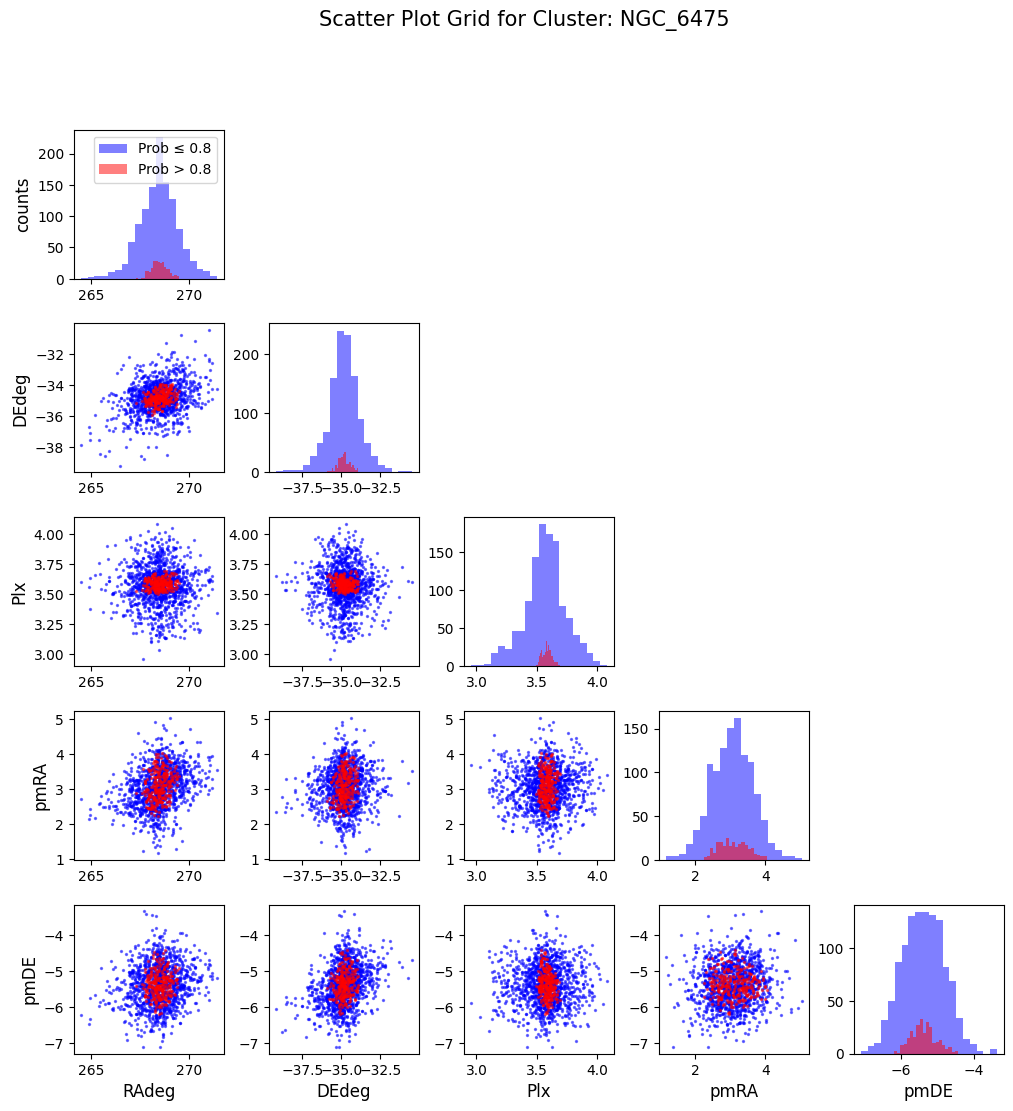

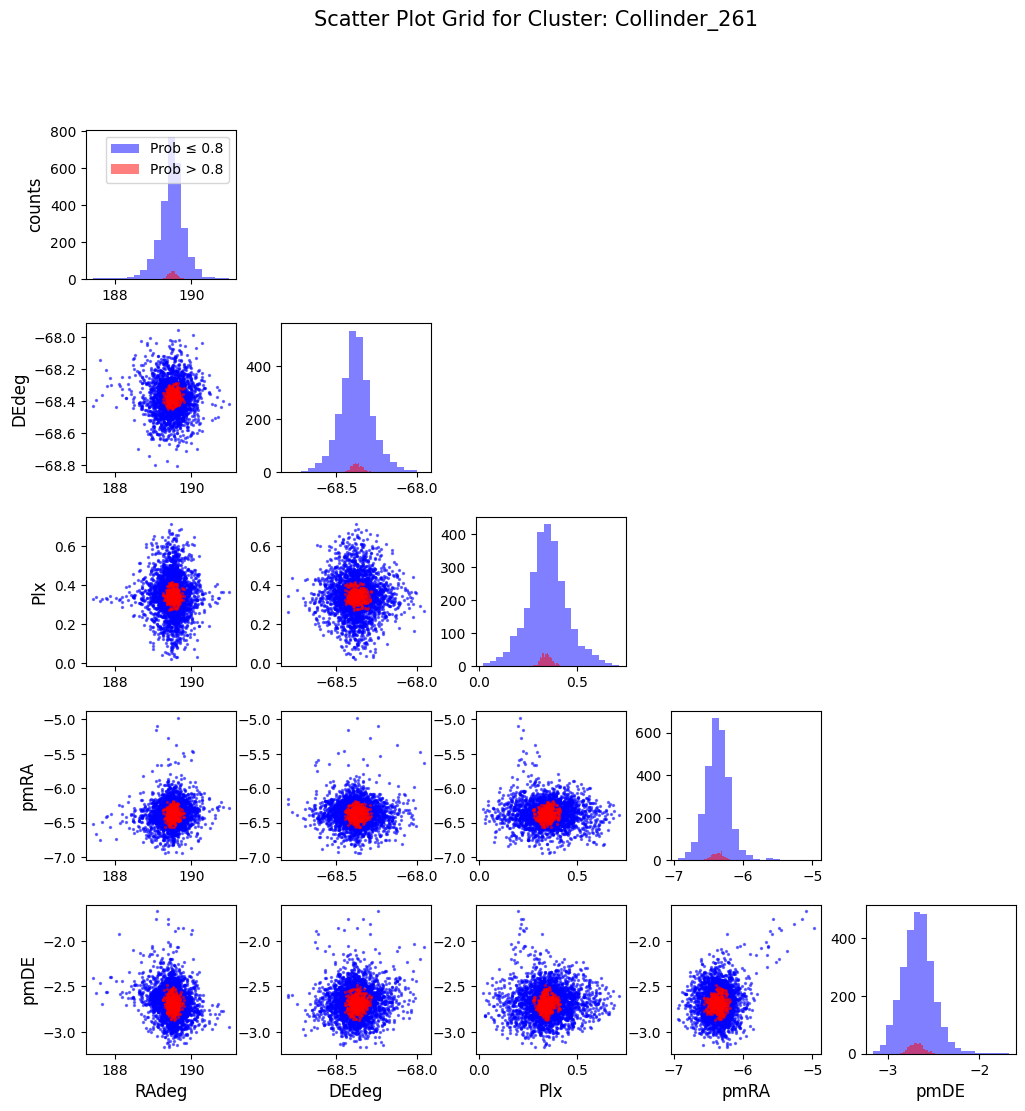

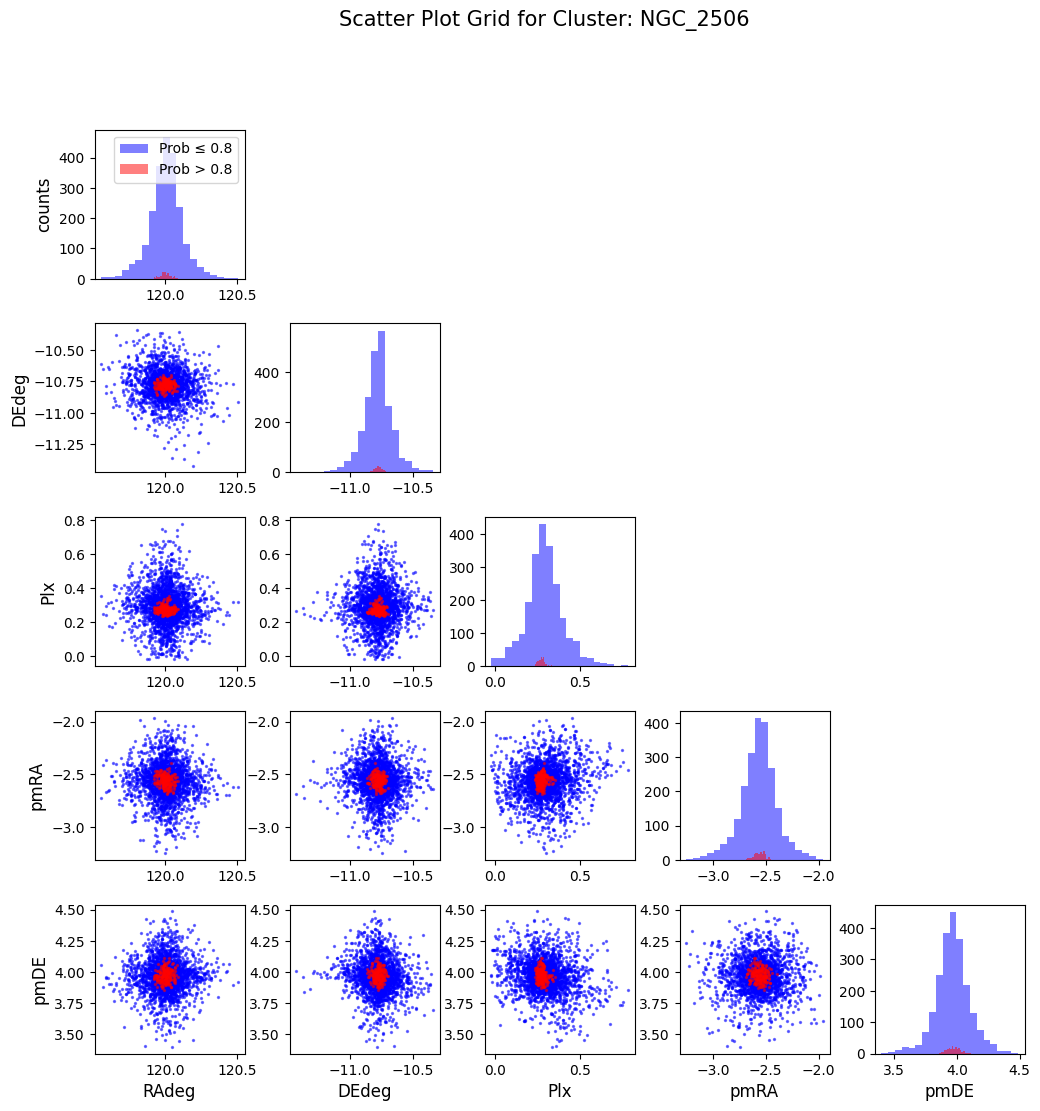

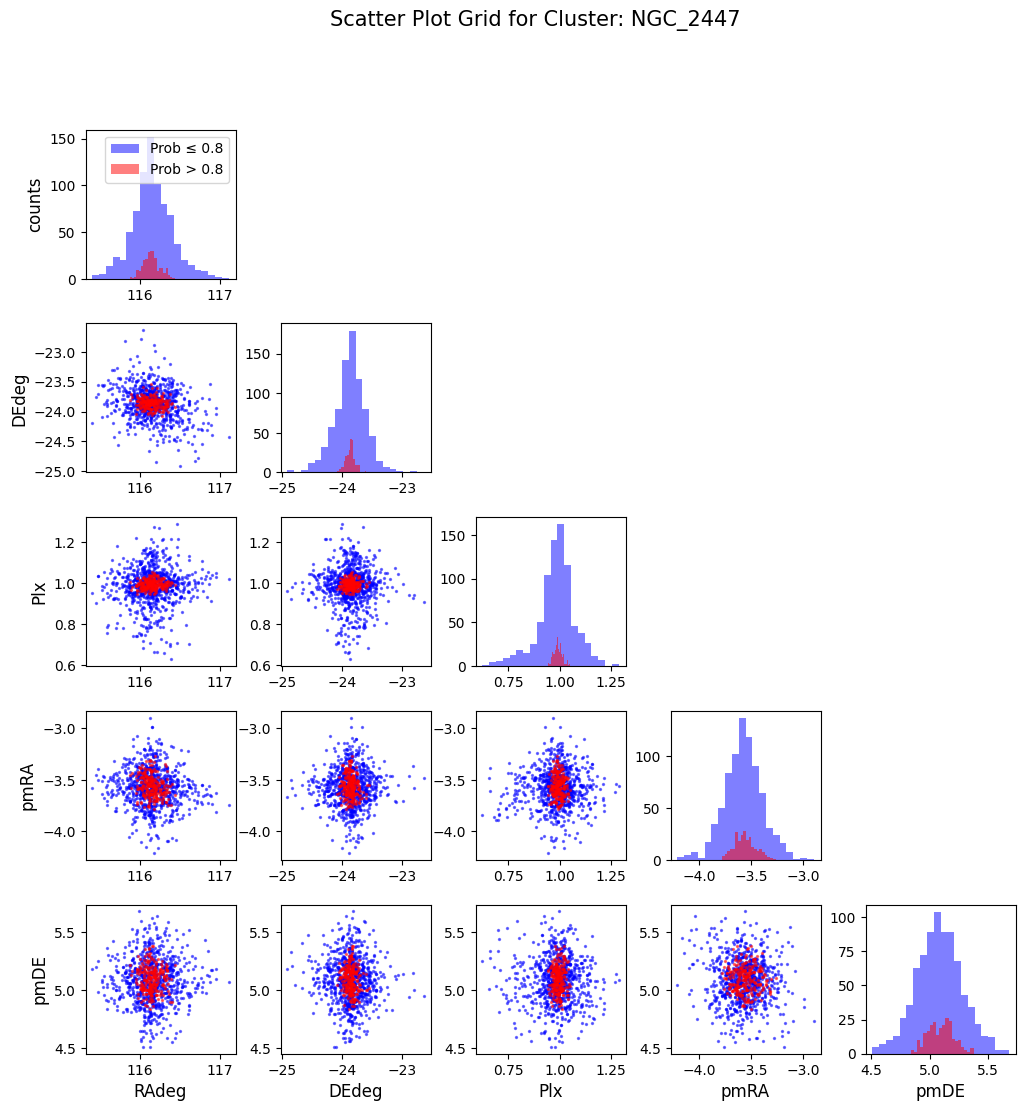

In [ ]:
# Assumptions: For this question we assume that the probability and physical characteristics of every star are independent of the others, 
# thus validating the comparisons made between both subsamples.

clusters = clcounts[clcounts['count'] > 1000]

# Randomly select 4 clusters
selected_clusters = clusters.sample(n=4, random_state=42)  # Random seed for reproducibility
selected_cluster_names = selected_clusters['Name'].tolist()

# Loop through selected clusters
for cluster_name in selected_cluster_names:
    # Filter data for the current cluster
    cluster_data = stars[stars['Name'] == cluster_name]
    
    # Split into two subsamples based on Prob
    subsample_lowp = cluster_data[cluster_data['Prob'] <= 0.8]
    subsample_highp = cluster_data[cluster_data['Prob'] > 0.8]
    
    # Define the 5-D parameter space
    params = ['RAdeg', 'DEdeg', 'Plx', 'pmRA', 'pmDE']
    ndims = len(params)
    
    # Plot
    fig, axes = plt.subplots(ndims, ndims, figsize=(12, 12))
    fig.subplots_adjust(wspace=0.3, hspace=0.3)
    
    # Grid of plots
    for i in range(ndims):  # Y-dimension
        for j in range(ndims):  # X-dimension
            if i == j:
                # Diagonal: Histogram
                axes[i, j].hist( subsample_lowp[params[i]], bins=20, alpha=0.5, color='blue', label='Prob ≤ 0.8' )
                axes[i, j].hist( subsample_highp[params[i]], bins=20, alpha=0.5, color='red', label='Prob > 0.8')
            
            elif i > j:
                # Lower triangle: Scatter plot
                axes[i, j].scatter( subsample_lowp[params[j]], subsample_lowp[params[i]], alpha=0.5, color='blue', label='Prob ≤ 0.8' , s = 2)
                axes[i, j].scatter( subsample_highp[params[j]], subsample_highp[params[i]], alpha=0.5, color='red', label='Prob > 0.8' , s = 2)
            
            else:
                # Upper triangle
                axes[i, j].axis('off')
            
            # Add labels
            if j == 0:
                if i == j:
                    axes[i, j].set_ylabel('Counts', fontsize=12)
                
                else:
                    axes[i, j].set_ylabel(params[i], fontsize=12)
            
            if i == ndims - 1:
                axes[i, j].set_xlabel(params[j], fontsize=12)
    
    # Add a legend to the diagonal histogram in the first row
    axes[0, 0].legend( fontsize=10)
    
    # Set the title for the figure
    fig.suptitle(f"Scatter Plot Grid for Cluster: {cluster_name}", fontsize=15)
    
    # Show the plot
    plt.show()


# Validation of Assumptions: Given the large number of selected clusters and the high count threshold, the sample sizes of the subsamples (low and high probability) 
# should be adequate for visual comparisons. Using histograms and scatter plots enables us to visually evaluate the relationship between the variables. 
# The Central Limit Theorem should hold as long as the clusters include a sufficiently large number of stars. 

# Results: We notice that the red dots associated with the higher probability are distributed in the center of the cluster. These stars are more likely to belong in the cluster, 
# and less scattered compared to the blue points. In general, the higher probability the more accurate represesentation of the cluster's properties, 
# in contrast with the blue points that the physical properties deviate from the center 

## Question 2 - Brief Explanation 

This question examines the distributions of various physical parameters (Plx, pmRA, pmDE, Gmag, BP-RP) among high-probability stars in the selected stellar clusters. 
The clusters containing over 200 stars and exhibiting low scatter in right ascension (RAdeg) and declination (DEdeg) are selected for the analysis. 
For each cluster, the stars are divided into subsamples based on whether their RA or Dec values are above or below the cluster's mean. 
Histograms are used to visualize the distributions of these parameters for the subsamples, as well as t-tests to assess whether the differences between the subsamples are statistically significant.

In [87]:
# Assumptions: Independence between observations is assumed. The analysis presumes that the size of each subsample is sufficiently large for the Central Limit Theorem to be applicable.
# Also, the t-tests assume that there is equal variance between the two subsamples.


stars_hiprob = stars[stars.Prob > 0.8]
clusters_hiprob = stars_hiprob.groupby(['Name']).size().reset_index(name='count')
clusters_sd_hiprob = stars_hiprob.groupby(['Name']).std(numeric_only=True).reset_index()
clusters_hiprob['sd_RAdeg'] = clusters_sd_hiprob['RAdeg']
clusters_hiprob['sd_DEdeg'] = clusters_sd_hiprob['DEdeg']

# Filter clusters with >200 stars and standard deviations <0.1
selected_clusters = clusters_hiprob[ (clusters_hiprob['count'] > 200) & 
    (clusters_hiprob['sd_RAdeg'] < 0.1) & (clusters_hiprob['sd_DEdeg'] < 0.1)]


In [ ]:

def distribution_cluster(cluster_name):
    """
    This function analyzes the distribution of various parameters within a cluster by splitting the data 
    into subsamples based on RA and Dec values. It generates histograms and performs t-tests for the subsamples.

    Parameters:
    cluster_name : str
        The name of the cluster to analyze. It should correspond to the 'Name' field in the stars_hiprob.

    Returns:
    None
        The function generates histograms to visualize the distributions of parameters for 
        RA and Dec subsamples, and prints the results of t-tests for these subsamples.
    """
    # Collect data from given cluster
    cluster_data = stars_hiprob[stars_hiprob['Name'] == cluster_name]

    # Split by RA and Dec
    mean_RA = cluster_data['RAdeg'].mean()
    mean_DE = cluster_data['DEdeg'].mean()

    subsample_RA1 = cluster_data[cluster_data['RAdeg'] > mean_RA]
    subsample_RA2 = cluster_data[cluster_data['RAdeg'] <= mean_RA]

    subsample_DE1 = cluster_data[cluster_data['DEdeg'] > mean_DE]
    subsample_DE2 = cluster_data[cluster_data['DEdeg'] <= mean_DE]

    # Plot histograms for RA subsamples
    params = ['Plx', 'pmRA', 'pmDE', 'Gmag', 'BP-RP']
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.suptitle(f"Cluster: {cluster_name} - RA Subsamples", fontsize=16)

    for i, param in enumerate(params):
        axes[i].hist(subsample_RA1[param], bins=20, alpha=0.5, color='blue', label='RA > Mean')
        axes[i].hist(subsample_RA2[param], bins=20, alpha=0.5, color='red', label='RA ≤ Mean')
        axes[i].set_title(param)
        axes[i].legend()

    plt.show()

    # Plot histograms for Dec subsamples
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.suptitle(f"Cluster: {cluster_name} - Dec Subsamples", fontsize=16)

    for i, param in enumerate(params):
        axes[i].hist(subsample_DE1[param], bins=20, alpha=0.5, color='blue', label='Dec > Mean')
        axes[i].hist(subsample_DE2[param], bins=20, alpha=0.5, color='red', label='Dec ≤ Mean')
        axes[i].set_title(param)
        axes[i].legend()

    plt.show()
    
    # t-tests for RA subsamples
    print(f"T-tests for RA subsamples in cluster: {cluster_name}")
    for param in params:
        t_stat, p_value = ttest_ind(subsample_RA1[param], subsample_RA2[param])
        print(f"{param}: t = {t_stat:.3f}, p-value = {p_value:.3e}")

    # t-tests for Dec subsamples
    print(f"\nT-tests for Dec subsamples in cluster: {cluster_name}")
    for param in params:
        t_stat, p_value = ttest_ind(subsample_DE1[param], subsample_DE2[param])
        print(f"{param}: t = {t_stat:.3f}, p-value = {p_value:.3e}")




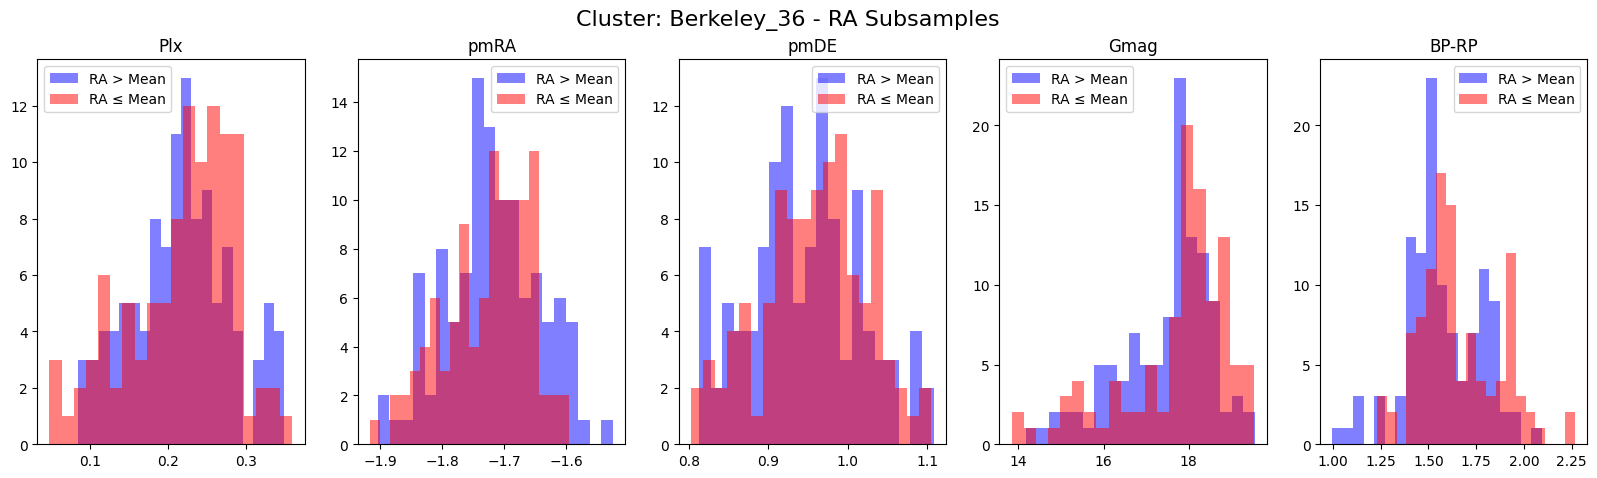

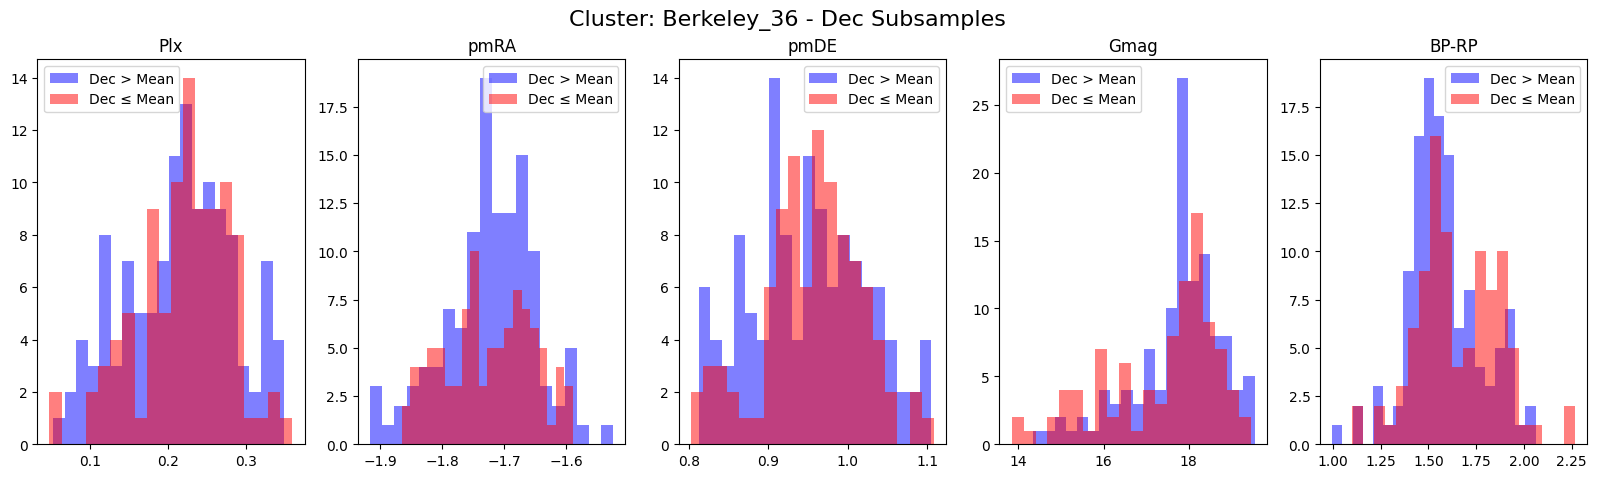

T-tests for RA subsamples in cluster: Berkeley_36
Plx: t = -0.019, p-value = 9.845e-01
pmRA: t = 0.922, p-value = 3.576e-01
pmDE: t = -1.397, p-value = 1.639e-01
Gmag: t = -1.452, p-value = 1.479e-01
BP-RP: t = -3.067, p-value = 2.441e-03

T-tests for Dec subsamples in cluster: Berkeley_36
Plx: t = -0.596, p-value = 5.521e-01
pmRA: t = 0.420, p-value = 6.749e-01
pmDE: t = -0.628, p-value = 5.305e-01
Gmag: t = 2.310, p-value = 2.184e-02
BP-RP: t = -2.708, p-value = 7.307e-03


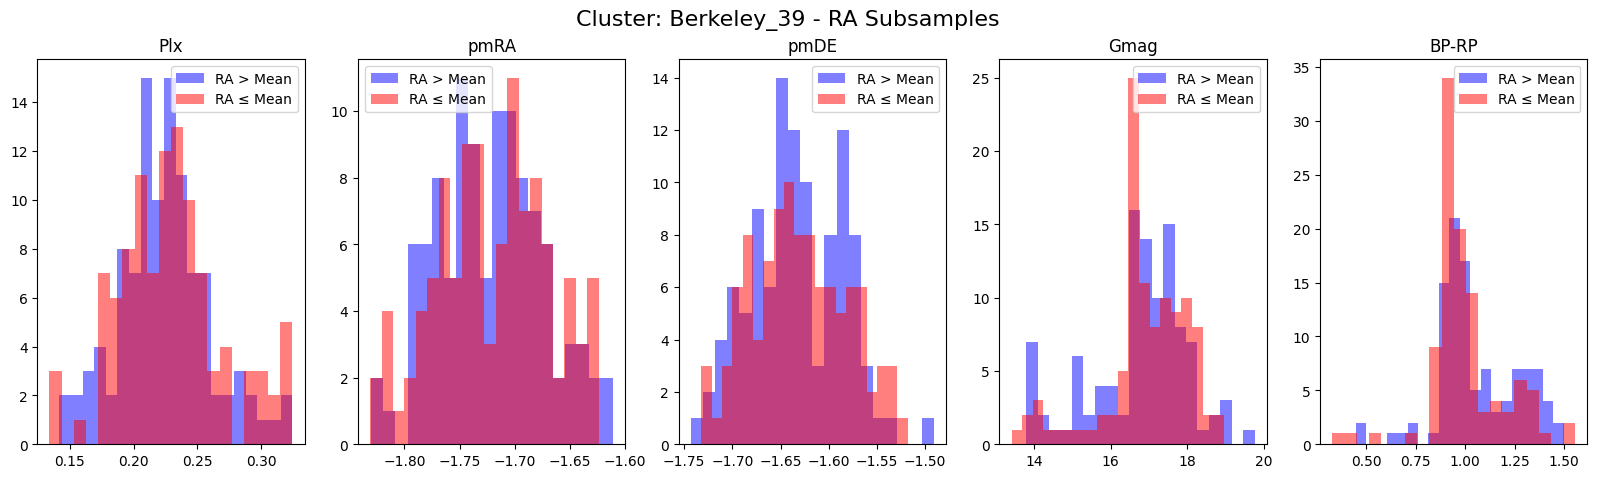

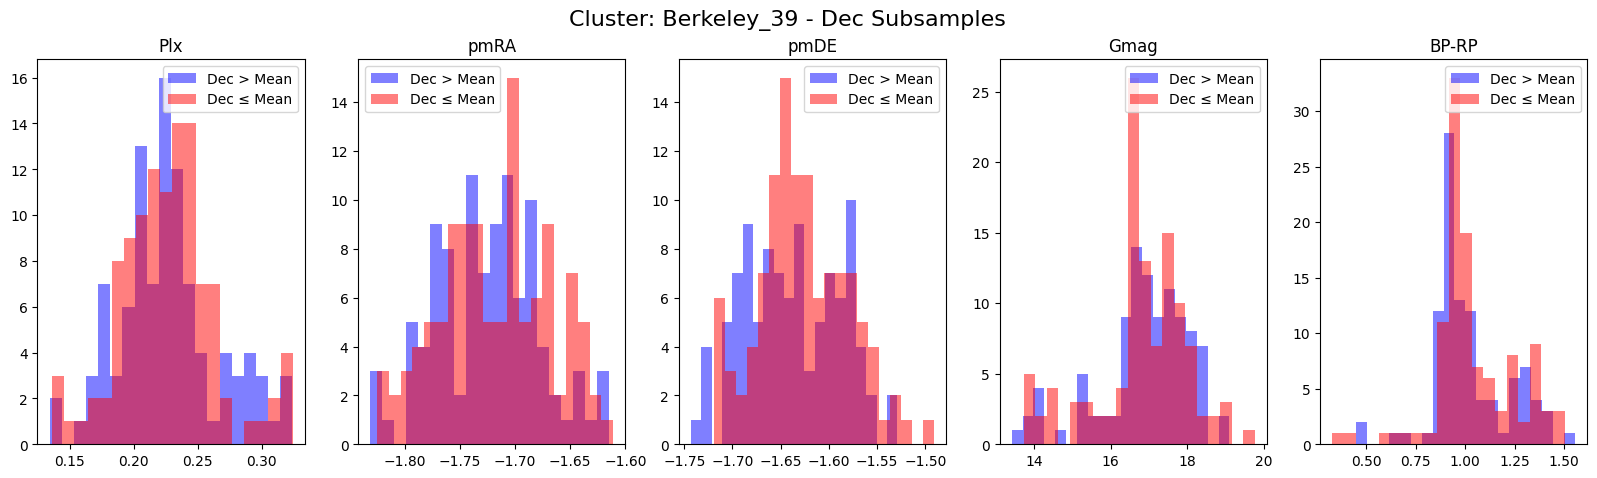

T-tests for RA subsamples in cluster: Berkeley_39
Plx: t = -1.068, p-value = 2.868e-01
pmRA: t = -0.287, p-value = 7.742e-01
pmDE: t = -0.415, p-value = 6.787e-01
Gmag: t = -0.921, p-value = 3.579e-01
BP-RP: t = 2.211, p-value = 2.811e-02

T-tests for Dec subsamples in cluster: Berkeley_39
Plx: t = 0.031, p-value = 9.752e-01
pmRA: t = -1.053, p-value = 2.934e-01
pmDE: t = -1.725, p-value = 8.600e-02
Gmag: t = 0.392, p-value = 6.953e-01
BP-RP: t = -0.754, p-value = 4.517e-01


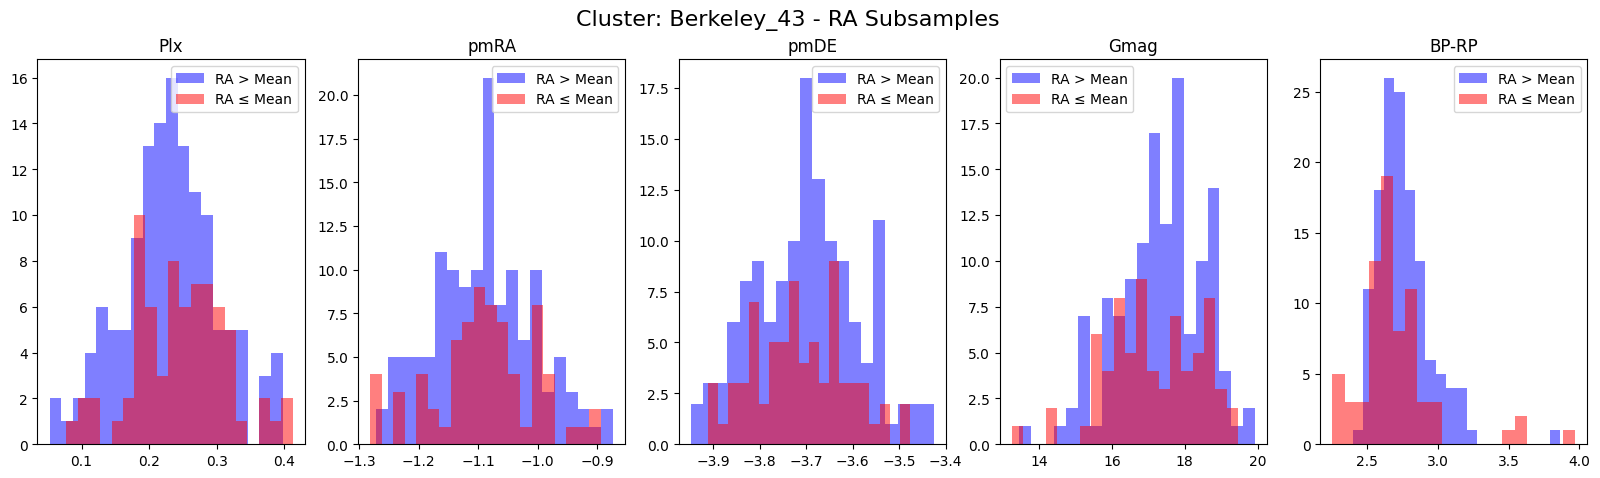

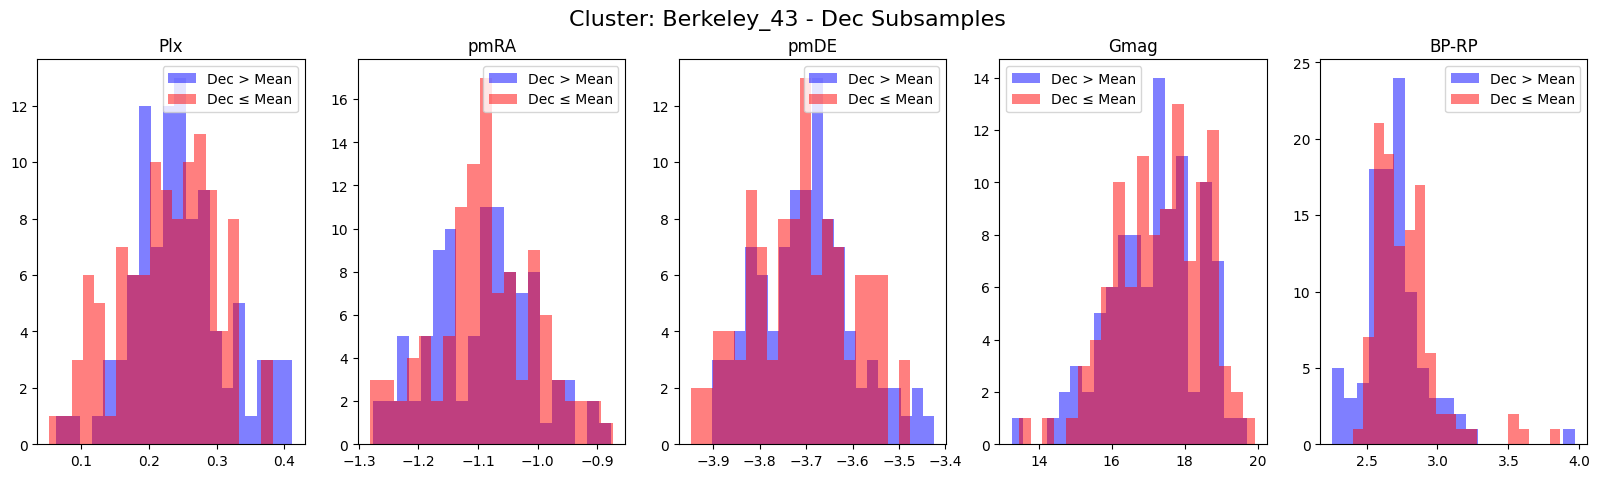

T-tests for RA subsamples in cluster: Berkeley_43
Plx: t = -1.514, p-value = 1.315e-01
pmRA: t = -0.039, p-value = 9.692e-01
pmDE: t = 0.820, p-value = 4.134e-01
Gmag: t = 1.267, p-value = 2.066e-01
BP-RP: t = 1.697, p-value = 9.124e-02

T-tests for Dec subsamples in cluster: Berkeley_43
Plx: t = 2.014, p-value = 4.528e-02
pmRA: t = -0.473, p-value = 6.370e-01
pmDE: t = 0.550, p-value = 5.826e-01
Gmag: t = -0.974, p-value = 3.312e-01
BP-RP: t = -2.311, p-value = 2.183e-02


In [89]:
# 3 different clusters
cluster_name1 = selected_clusters['Name'].iloc[0]
cluster_name2 = selected_clusters['Name'].iloc[1]
cluster_name3 = selected_clusters['Name'].iloc[2]

# Use the function 
distribution_cluster(cluster_name1)
distribution_cluster(cluster_name2)
distribution_cluster(cluster_name3)

# Results: b. Any of the parameters turns out being significantly different, means that the stars' properties are not homogeneous within the cluster and the population could change with position. 
# For the parallax parameter we seem to have non significant values for RA and DE, indicating that the distance is consistent across the cluster 
# Significant differences can be noticed for the pmRA and pmDE, so the proper motion of the cluster changes with position
# Gmag is weakly significant suggesting potential variations in the brightness with position. 
# BP-RP experiences significant diffences, indicating differences in the color across the cluster 

# c. An implication observed from the resulted data is that for Collinder_261, a significant difference in the Dec parameter is noticed. This can be explained due to assymetries of the cluster. 
# For the cluster NGC_6475, significant differences in proper motion can suggest internal dynamics. Finally, for NGC_2506 an implication is a significant difference in RA.
# Generally, t-tests can be used making assumption on the distributions and the equal variance of the parameters. Although, some clusters may seem to have assymmetries or difefrent dynamics along the subsamples
# making this method less applicable, overall the methdo can be applied and give robust results.



## Question 3 - Brief Explanation 

The question below examines key characteristics of high-probability stars within stellar clusters, specifically those with over 200 stars and a spatial size of less than 1 deg. 
It computes statistical properties for each cluster and a scatter matrix plot is produced to investigate the relationship among the parameters of mean parallax, 
standard deviation of parallax, spatial size, mean proper motion, and standard deviation of proper motion. 

In [ ]:
# Assumptions: The analysis presumes that the size of each subsample is sufficiently large for the Central Limit Theorem to be applicable. 
# The calculated values are based on the assumption that the data within each cluster reflects the properties of the cluster and is not influenced by observational errors.


clusters_hiprob = stars_hiprob.groupby(['Name']).size().reset_index(name='n_star')
clusters_sd_hiprob = stars_hiprob.groupby(['Name']).std(numeric_only=True).reset_index()
clusters_mean_hiprob = stars_hiprob.groupby(['Name']).mean(numeric_only=True).reset_index()

# Add mean parallax and parallax standard deviation
clusters_hiprob['mean_Parallax'] = clusters_mean_hiprob['Plx']
clusters_hiprob['sd_Parallax'] = clusters_sd_hiprob['Plx']

# Calculate cluster size (sigma_pos)
clusters_hiprob['sd_RAdeg'] = clusters_sd_hiprob['RAdeg']
clusters_hiprob['sd_DEdeg'] = clusters_sd_hiprob['DEdeg']
clusters_hiprob['sigma_pos'] = np.sqrt( clusters_hiprob['sd_RAdeg']**2 + clusters_hiprob['sd_DEdeg']**2 )

# Calculate mean proper motion (mean delta) and its standard deviation (sigma_delta)
clusters_hiprob['mean_pm'] = np.sqrt( clusters_mean_hiprob['pmRA']**2 + clusters_mean_hiprob['pmDE']**2 )

clusters_hiprob['sd_pmRA'] = clusters_sd_hiprob['pmRA']
clusters_hiprob['sd_pmDE'] = clusters_sd_hiprob['pmDE']

clusters_hiprob['sigma_pm'] = np.sqrt( clusters_hiprob['sd_pmRA']**2 + clusters_hiprob['sd_pmDE']**2 )

# Select clusters with n* > 200 and sigma_pos < 1 deg
filtered_clusters = clusters_hiprob[(clusters_hiprob['n_star'] > 200) & (clusters_hiprob['sigma_pos'] < 1)]

# Select only the required columns
specified_clusters_par = filtered_clusters[['Name','n_star', 'mean_Parallax', 'sd_Parallax', 'sigma_pos', 'mean_pm', 'sigma_pm']]

# Display the simplified dataframe
print(specified_clusters_par)




             Name  n_star  mean_Parallax  sd_Parallax  sigma_pos    mean_pm  \
135        BH_131     227       0.125637     0.046214   0.221680   6.536827   
137        BH_140     338       0.190195     0.043486   0.127424  14.897046   
161         BH_66     355       0.123089     0.044962   0.180838   5.470541   
217   Berkeley_36     217       0.217359     0.065872   0.063243   1.967901   
219   Berkeley_39     211       0.226982     0.038289   0.045639   2.371439   
...           ...     ...            ...          ...        ...        ...   
6763      UBC_461     231       0.298768     0.031775   0.419239   4.096675   
6805      UBC_517     256       0.405671     0.022682   0.716871   5.685520   
6872      UBC_600     390       0.171171     0.039550   0.721515   1.191558   
6926       UFMG_2     212       0.377292     0.026794   0.073233   5.382440   
6931      UFMG_38     246       0.297418     0.053870   0.137607   3.182825   

      sigma_pm  
135   0.154404  
137   0.129645  


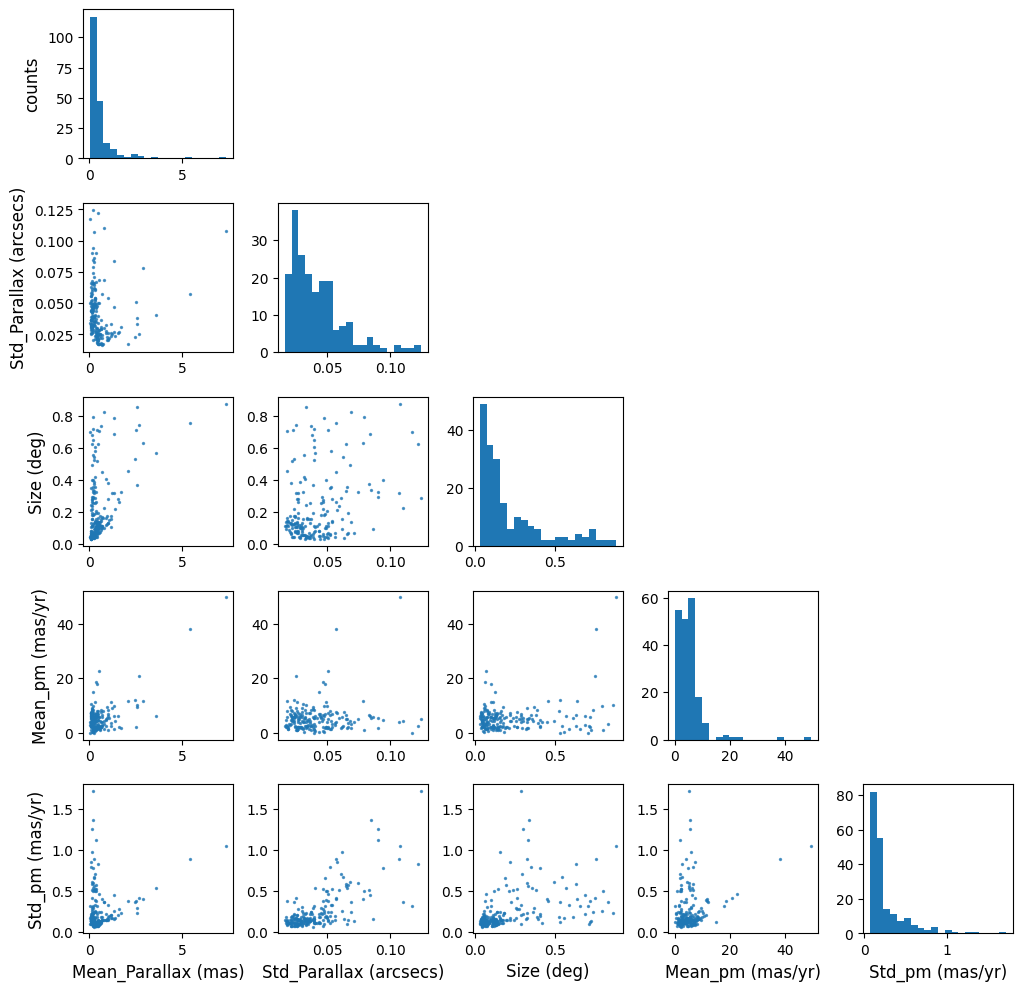

In [ ]:

# Extract relevant columns for plotting
quantities = filtered_clusters[['mean_Parallax', 'sd_Parallax', 'sigma_pos', 'mean_pm', 'sigma_pm']].values
labels = ['Mean_Parallax (mas)', 'Std_Parallax (arcsecs)', 'Size (deg)', 'Mean_pm (mas/yr)', 'Std_pm (mas/yr)']
ndims = quantities.shape[1]

# Create scatter matrix using the described method
fig, axes = plt.subplots(ndims, ndims, figsize=(12, 12))
fig.subplots_adjust(wspace=0.3, hspace=0.3)

for i in range(ndims):  # y dimension 
    for j in range(ndims):  # x dimension 
        if i == j:
            axes[i, j].hist(quantities[:, i], bins=20)
        elif i > j:
            axes[i, j].scatter(quantities[:, j], quantities[:, i], alpha=0.7, s = 2)
        else:
            axes[i, j].axis('off')

        # Add labels
        if j == 0:
            if i == j:
                axes[i, j].set_ylabel('Counts', fontsize=12)
            else:
                axes[i, j].set_ylabel(labels[i], fontsize=12)
        if i == ndims - 1:
            axes[i, j].set_xlabel(labels[j], fontsize=12)

# Show the plot
plt.show()


# Results: Mean parallax has a positive correlation with both cluster size and parallax dispersion, 
# indicating that nearby clusters tend to be more spatially extended. 
# Similarly, mean proper motion is positively correlated with proper motion dispersion suggesting that higher velocities are associated with more broad clusters. 
# The relationship between cluster size and mean proper motion seems insignificant. 
# These patterns reflect a mix of intrinsic characteristics of the clusters and observational effects, derived form the data.

## Question 4 - Brief Explanation 

The cells below calculate Pearson's r and Spearman's rho correlations for both the original and log-transformed data to evaluate the relationships between parameters. 
Pearson's r is used to measure linear correlations, whereas Spearman's rho is effective for identifying monotonic relationships. 

In [ ]:
# Assumptions: The quantities may display multiplicative behavior. The Pearson's r assumes a linear relationship between variables, 
# while Spearman's rho assumes monotonicity.

# Matrices for Pearson and Spearman correlations
pearson_r = np.zeros((ndims, ndims))
pearson_p = np.zeros((ndims, ndims))
spearman_rho = np.zeros((ndims, ndims))
spearman_p = np.zeros((ndims, ndims))

# Compute correlations for original data
for i in range(ndims):  # Rows
    for j in range(i):  # Columns
        # Pearson's r
        r, p_r = sps.pearsonr(quantities[:, j], quantities[:, i])
        pearson_r[i, j] = r
        pearson_p[i, j] = p_r

        # Spearman's rho
        rho, p_rho = sps.spearmanr(quantities[:, j], quantities[:, i])
        spearman_rho[i, j] = rho
        spearman_p[i, j] = p_rho


# results into dataframes 
pearson_r_df = pd.DataFrame(pearson_r, index=labels, columns=labels)
pearson_p_df = pd.DataFrame(pearson_p, index=labels, columns=labels)
spearman_rho_df = pd.DataFrame(spearman_rho, index=labels, columns=labels)
spearman_p_df = pd.DataFrame(spearman_p, index=labels, columns=labels)


# Results
print("Pearson's r Correlation Matrix")
print(pearson_r_df)
print("\n Pearson's p-value Matrix")
print(pearson_p_df)

print("\n Spearman's rho Correlation Matrix")
print(spearman_rho_df)
print("\n Spearman's p-value Matrix")
print(spearman_p_df)



Pearson's r Correlation Matrix
                        Mean_Parallax (mas)  Std_Parallax (arcsecs)  \
Mean_Parallax (mas)                0.000000                0.000000   
Std_Parallax (arcsecs)             0.047611                0.000000   
Size (deg)                         0.476555                0.341305   
Mean_pm (mas/yr)                   0.668548                0.129134   
Std_pm (mas/yr)                    0.228468                0.713024   

                        Size (deg)  Mean_pm (mas/yr)  Std_pm (mas/yr)  
Mean_Parallax (mas)       0.000000          0.000000              0.0  
Std_Parallax (arcsecs)    0.000000          0.000000              0.0  
Size (deg)                0.000000          0.000000              0.0  
Mean_pm (mas/yr)          0.236015          0.000000              0.0  
Std_pm (mas/yr)           0.403202          0.264974              0.0  

 Pearson's p-value Matrix
                        Mean_Parallax (mas)  Std_Parallax (arcsecs)  \
Mean_Paralla

In [ ]:
# Convert the data in log
log_data = np.log(quantities)

# Matrices for log-transformed data
log_pearson_r = np.zeros((ndims, ndims))
log_pearson_p = np.zeros((ndims, ndims))
log_spearman_rho = np.zeros((ndims, ndims))
log_spearman_p = np.zeros((ndims, ndims))

# Compute correlations for log-transformed data
for i in range(ndims):  # Rows
    for j in range(i):  # Columns
        # Pearson's r
        r_log, p_r_log = sps.pearsonr(log_data[:, j], log_data[:, i])
        log_pearson_r[i, j] = r_log
        log_pearson_p[i, j] = p_r_log

        # Spearman's rho
        rho_log, p_rho_log = sps.spearmanr(log_data[:, j], log_data[:, i])
        log_spearman_rho[i, j] = rho_log
        log_spearman_p[i, j] = p_rho_log

log_pearson_r_df = pd.DataFrame(log_pearson_r, index=labels, columns=labels)
log_pearson_p_df = pd.DataFrame(log_pearson_p, index=labels, columns=labels)
log_spearman_rho_df = pd.DataFrame(log_spearman_rho, index=labels, columns=labels)
log_spearman_p_df = pd.DataFrame(log_spearman_p, index=labels, columns=labels)

print(" Log-Transformed Pearson's r Correlation Matrix ")
print(log_pearson_r_df)
print("\n Log-Transformed Pearson's p-value Matrix ")
print(log_pearson_p_df)

print("\n Log-Transformed Spearman's rho Correlation Matrix ")
print(log_spearman_rho_df)
print("\n Log-Transformed Spearman's p-value Matrix ")
print(log_spearman_p_df)


# Results: a. Some paramaters show strong linear correlation based on the Pearson's parameters, whereas other show weak correlation (small r).
# Pearson's r assumes that the data are roughly normally distributed. However, some variables, like parallax and proper motion, have a non-normal distributions. 
# This could compromise the validity of Pearson's correlation. On the other hand, Spearman's rho does not require normality and is more suitable for monotonic relationships. 
# For variables that may have nonlinear trends, Spearman's correlation offers greater robustness. I believe that Spearman's rho is a better choice for this data.
# 
# b. The log transformation is implimented to normalize the data, improving the reliability of the parameters 
# As Pearson's parameter, assumes linearity, using log transformation the data become more symmetric. 
# On the other hand, Spearman's parameter with the log transformation also reduces assymetries, and helps look at the 
# data in more 'clear' way.
# Some instances of the correlation between the different parameters are:
# std_paralax and std_pm have a strong linear correlation as the r value is significant, and their p-value is really small.
# A weak correlation can be seen between the mean_pm and std_pm parameters where the r is very small and the p value is more significant.
# Regarding the monotonic correlation based on the Sperasman's rho, there is strong correlation between std_Parallax and std_pm with 
# a large rho value and small p-value. An insignificant monotonic correlation is between mean_parallax and size where rho is smaller.
# In general, the log transformationa has help identify the correlation between the parameters in a more secure way.
# Some implications are that The stronger correlations found in the transformed data reveal underlying relationships that are hidden in the raw data.

 Log-Transformed Pearson's r Correlation Matrix 
                        Mean_Parallax (mas)  Std_Parallax (arcsecs)  \
Mean_Parallax (mas)                0.000000                0.000000   
Std_Parallax (arcsecs)            -0.252036                0.000000   
Size (deg)                         0.428522                0.264515   
Mean_pm (mas/yr)                   0.196391               -0.002964   
Std_pm (mas/yr)                    0.111445                0.673524   

                        Size (deg)  Mean_pm (mas/yr)  Std_pm (mas/yr)  
Mean_Parallax (mas)       0.000000          0.000000              0.0  
Std_Parallax (arcsecs)    0.000000          0.000000              0.0  
Size (deg)                0.000000          0.000000              0.0  
Mean_pm (mas/yr)         -0.027338          0.000000              0.0  
Std_pm (mas/yr)           0.557149          0.169528              0.0  

 Log-Transformed Pearson's p-value Matrix 
                        Mean_Parallax (mas)  Std